# Proyek Analisis Data: Bike Sharing Dataset
- **Nama:** Muhamad Aditya Umar Faiz
- **Email:** umaygans03@gmail.com
- **ID Dicoding:** muhamad_aditya_umar

![Screenshot 2026-01-03 104333.png](<attachment:Screenshot 2026-01-03 104333.png>)
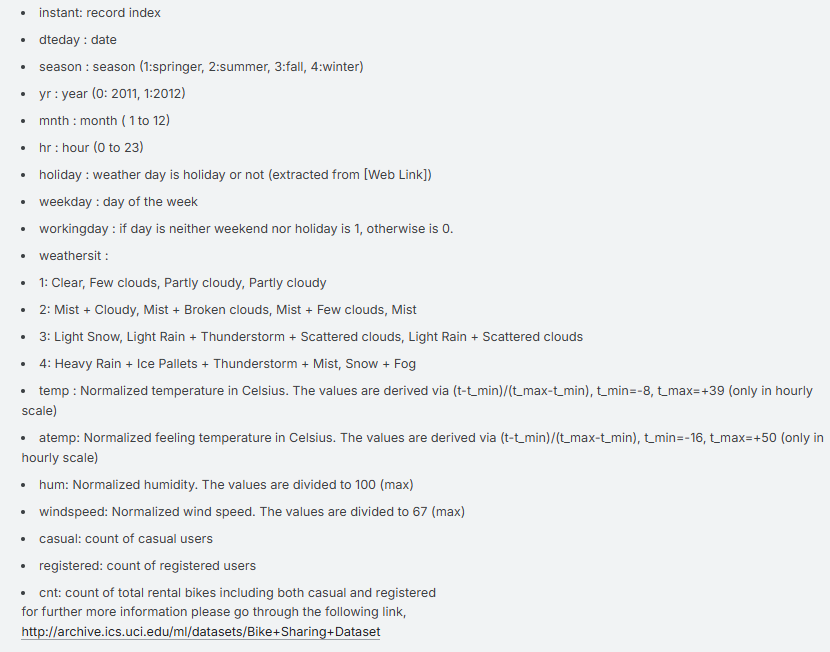

## Menentukan Pertanyaan Bisnis

1. Bagaimana perbedaan rata-rata jumlah peminjaman sepeda harian pada setiap kondisi cuaca selama periode pengamatan dataset?
2. Bagaimana perbedaan rata-rata jumlah peminjaman sepeda harian antara hari kerja dan akhir pekan di periode tertentu?


## Import Semua Packages/Library yang Digunakan

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [56]:
import pandas as pd

df = pd.read_csv("data/day.csv")
df["dteday"] = pd.to_datetime(df["dteday"])

weather_map = {
    1: "Clear",
    2: "Mist+Cloudy",
    3: "Light Rain",
    4: "Heavy Rain"
}
df["weather"] = df["weathersit"].map(weather_map)

df["day_type"] = "Weekend"
df.loc[df["workingday"] == 1, "day_type"] = "Working Day"
df.loc[df["holiday"] == 1, "day_type"] = "Holiday"

df.to_csv("dashboard/main_data.csv", index=False)


## Data Wrangling

### Gathering Data

In [14]:
df = pd.read_csv('data/day.csv')

df.head(10)

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,2011-01-02,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,2011-01-03,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,4,2011-01-04,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,5,2011-01-05,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600
5,6,2011-01-06,1,0,1,0,4,1,1,0.204348,0.233209,0.518261,0.089565,88,1518,1606
6,7,2011-01-07,1,0,1,0,5,1,2,0.196522,0.208839,0.498696,0.168726,148,1362,1510
7,8,2011-01-08,1,0,1,0,6,0,2,0.165000,0.162254,0.535833,0.266804,68,891,959
8,9,2011-01-09,1,0,1,0,0,0,1,0.138333,0.116175,0.434167,0.361950,54,768,822
9,10,2011-01-10,1,0,1,0,1,1,1,0.150833,0.150888,0.482917,0.223267,41,1280,1321


In [4]:
df.shape


(731, 16)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     731 non-null    int64  
 1   dteday      731 non-null    object 
 2   season      731 non-null    int64  
 3   yr          731 non-null    int64  
 4   mnth        731 non-null    int64  
 5   holiday     731 non-null    int64  
 6   weekday     731 non-null    int64  
 7   workingday  731 non-null    int64  
 8   weathersit  731 non-null    int64  
 9   temp        731 non-null    float64
 10  atemp       731 non-null    float64
 11  hum         731 non-null    float64
 12  windspeed   731 non-null    float64
 13  casual      731 non-null    int64  
 14  registered  731 non-null    int64  
 15  cnt         731 non-null    int64  
dtypes: float64(4), int64(11), object(1)
memory usage: 91.5+ KB


**Insight:**
- Dataset yang digunakan adalah day.csv, karena analisis difokuskan pada peminjaman sepeda harian, sehingga data per jam pada hour.csv tidak digunakan pada tahap ini.
- Sebagian besar kolom pada dataset bertipe numerik (int64 dan float64), sehingga memudahkan proses analisis statistik dan pembuatan visualisasi.
- Kolom dteday masih bertipe object, sehingga perlu dikonversi menjadi tipe datetime untuk mendukung analisis berbasis waktu.



### Assessing Data

In [6]:
df.isna().sum()

instant       0
dteday        0
season        0
yr            0
mnth          0
holiday       0
weekday       0
workingday    0
weathersit    0
temp          0
atemp         0
hum           0
windspeed     0
casual        0
registered    0
cnt           0
dtype: int64

In [7]:
df.duplicated().sum()

np.int64(0)

In [8]:
df.dtypes

instant         int64
dteday         object
season          int64
yr              int64
mnth            int64
holiday         int64
weekday         int64
workingday      int64
weathersit      int64
temp          float64
atemp         float64
hum           float64
windspeed     float64
casual          int64
registered      int64
cnt             int64
dtype: object

In [15]:
df['weathersit'].value_counts().sort_index()

weathersit
1    463
2    247
3     21
Name: count, dtype: int64

In [10]:
df.describe()

,instant,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000
mean,366.000000,2.496580,0.500684,6.519836,0.028728,2.997264,0.683995,1.395349,0.495385,0.474354,0.627894,0.190486,848.176471,3656.172367,4504.348837
std,211.165812,1.110807,0.500342,3.451913,0.167155,2.004787,0.465233,0.544894,0.183051,0.162961,0.142429,0.077498,686.622488,1560.256377,1937.211452
min,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.059130,0.079070,0.000000,0.022392,2.000000,20.000000,22.000000
25%,183.500000,2.000000,0.000000,4.000000,0.000000,1.000000,0.000000,1.000000,0.337083,0.337842,0.520000,0.134950,315.500000,2497.000000,3152.000000
50%,366.000000,3.000000,1.000000,7.000000,0.000000,3.000000,1.000000,1.000000,0.498333,0.486733,0.626667,0.180975,713.000000,3662.000000,4548.000000
75%,548.500000,3.000000,1.000000,10.000000,0.000000,5.000000,1.000000,2.000000,0.655417,0.608602,0.730209,0.233214,1096.000000,4776.500000,5956.000000
max,731.000000,4.000000,1.000000,12.000000,1.000000,6.000000,1.000000,3.000000,0.861667,0.840896,0.972500,0.507463,3410.000000,6946.000000,8714.000000


**Insight:**
- untuk missing value tidak ada
- duplikasi data tidak ada
- Kolom dteday masih bertipe object,Perlu konversi ke datetime
- untuk kategori hanya muncul 3 di dokumentasi ada 4. dan ternyata weather yang keempat hanya muncul pada data hours.csv

### Cleaning Data

In [16]:
df['dteday'] = pd.to_datetime(df['dteday'])

In [18]:
weather_map = {
    1: "Clear",
    2: "Mist+Cloudy",
    3: "Light Rain",
    4: "Heavy Rain"
}

df['weather'] = df['weathersit'].map(weather_map)


In [28]:
df['day_type'] = 'Weekend'

df.loc[df['workingday'] == 1, 'day_type'] = 'Working Day'
df.loc[df['holiday'] == 1, 'day_type'] = 'Holiday'


In [29]:
df[['dteday', 'weather', 'day_type']].head()

,dteday,weather,day_type
0,2011-01-01,Mist+Cloudy,Weekend
1,2011-01-02,Mist+Cloudy,Weekend
2,2011-01-03,Clear,Working Day
3,2011-01-04,Clear,Working Day
4,2011-01-05,Clear,Working Day


In [30]:
df[['weather', 'day_type']].isna().sum()

weather     0
day_type    0
dtype: int64

**Insight:**
- Kolom dteday dikonversi ke tipe datetime untuk analisis berbasis waktu
- Variabel kategorikal seperti kondisi cuaca dipetakan ke label deskriptif untuk memudahkan interpretasi
- kolom day_type untuk membedakan hari kerja (Working Day), akhir pekan (Weekend), dan hari libur (Holiday)
- Tidak ditemukan nilai kosong setelah proses pembersihan, sehingga data siap digunakan untuk tahap analisis selanjutnya

## Exploratory Data Analysis (EDA)

### Explore ...

### Gambaran Umum Peminjaman

In [31]:
df['cnt'].describe()

count     731.000000
mean     4504.348837
std      1937.211452
min        22.000000
25%      3152.000000
50%      4548.000000
75%      5956.000000
max      8714.000000
Name: cnt, dtype: float64

### EDA Pertanyaan 1

In [32]:
df.groupby('weather')['cnt'].mean().reset_index()


,weather,cnt
0,Clear,4876.786177
1,Light Rain,1803.285714
2,Mist+Cloudy,4035.862348


### Pertanyaan 2

In [34]:
df['day_type'].value_counts()


day_type
Working Day    500
Weekend        210
Holiday         21
Name: count, dtype: int64

In [ ]:
df.groupby('day_type')['cnt'].mean().reset_index()

,day_type,cnt
0,Holiday,3735.000000
1,Weekend,4389.685714
2,Working Day,4584.820000


**Insight:**
- Rata-rata peminjaman sepeda harian tertinggi terjadi saat cuaca cerah (Clear)
- Pada kondisi Mist+Cloudy, peminjaman menurun namun masih relatif tinggi
- Hujan ringan (Light Rain) menyebabkan penurunan peminjaman paling signifikan, menunjukkan cuaca buruk menghambat penggunaan sepeda
<br>

- Working Day memiliki rata-rata peminjaman tertinggi, menandakan sepeda banyak digunakan aktivitas rutin
- Weekend berada di tingkat menengah dengan peminjaman sedikit lebih rendah dari hari kerja
- Holiday memiliki rata-rata peminjaman terendah, menunjukkan pola penggunaan yang lebih tidak konsisten dibandingkan hari kerja dan akhir pekan


## Visualization & Explanatory Analysis

### Pertanyaan 1:

In [42]:
weather_order = ["Clear", "Mist+Cloudy", "Light Rain", "Heavy Rain"]
day_order = ["Working Day", "Weekend", "Holiday"]
weather_avg = df.groupby("weather")["cnt"].mean().reindex(weather_order).reset_index()


sns.set_theme(
    style="whitegrid",
    context="talk",
    rc={
        "grid.linestyle": "--",
        "grid.alpha": 0.6,
        "axes.edgecolor": "#333333",
        "axes.linewidth": 1
    }
)



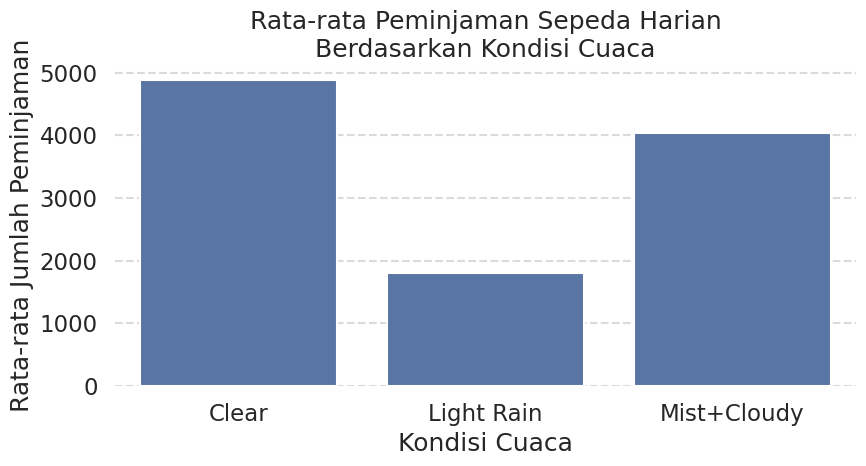

In [ ]:
weather_avg = (
    df.groupby("weather")["cnt"]
      .mean()
      .reset_index()
)

plt.figure(figsize=(9, 5))
ax = sns.barplot(
    data=weather_avg,
    x="weather",
    y="cnt",
    color="#4C72B0"
)

ax.set_title("Rata-rata Peminjaman Sepeda Harian\nBerdasarkan Kondisi Cuaca")
ax.set_xlabel("Kondisi Cuaca")
ax.set_ylabel("Rata-rata Jumlah Peminjaman")
ax.grid(axis="y", linestyle="--", alpha=0.7)
sns.despine(left=True, bottom=True)

plt.tight_layout()
plt.show()


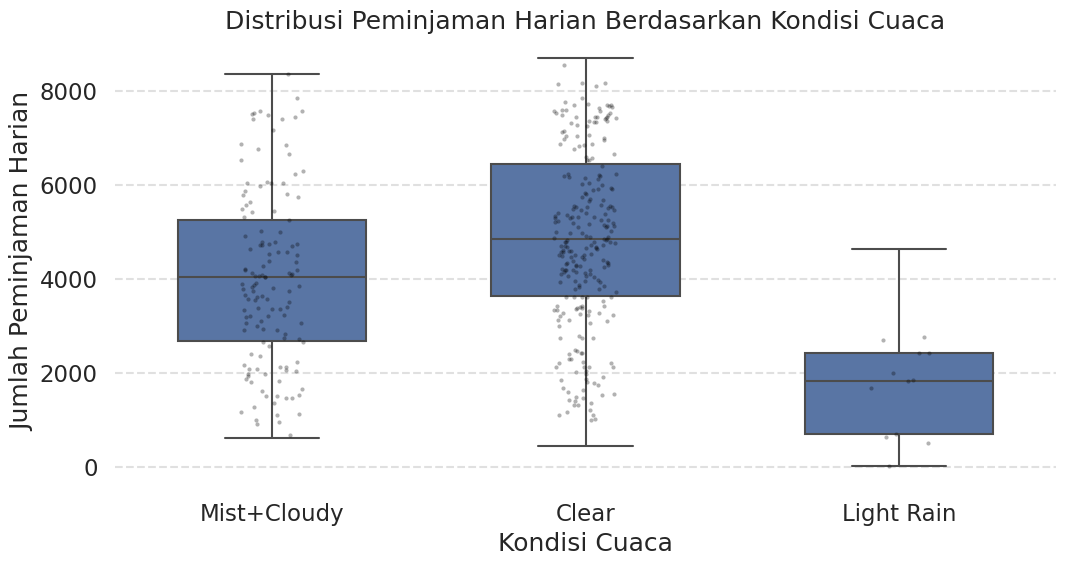

In [55]:
plt.figure(figsize=(11, 6))
ax = sns.boxplot(
    data=df,
    x="weather",
    y="cnt",
    showfliers=False,
    width=0.6,
    linewidth=1.5
)

sns.stripplot(
    data=df.sample(min(len(df), 400), random_state=42),
    x="weather",
    y="cnt",
    color="black",
    size=3,
    alpha=0.3
)

ax.set_title("Distribusi Peminjaman Harian Berdasarkan Kondisi Cuaca")
ax.set_xlabel("Kondisi Cuaca")
ax.set_ylabel("Jumlah Peminjaman Harian")
ax.grid(axis="y", linestyle="--", alpha=0.6)
sns.despine(left=True, bottom=True)

plt.tight_layout()
plt.show()


### Pertanyaan 2:

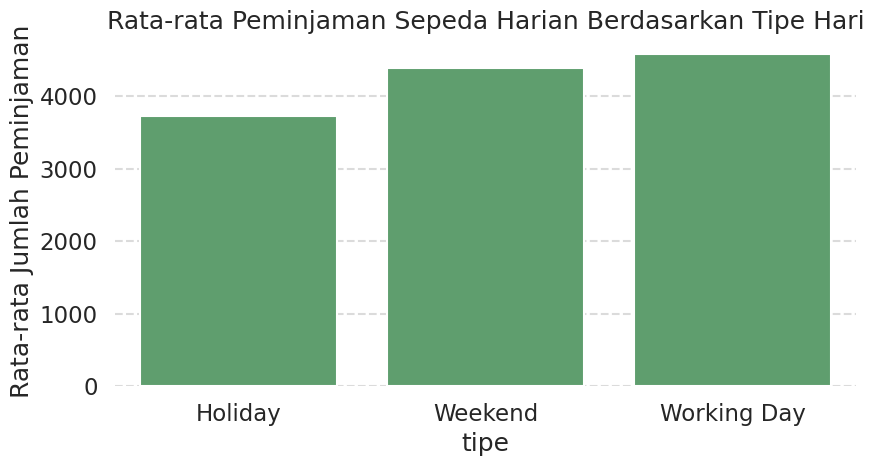

In [53]:
day_avg = (
    df.groupby("day_type")["cnt"]
      .mean()
      .reset_index()
)

plt.figure(figsize=(9, 5))
ax = sns.barplot(
    data=day_avg,
    x="day_type",
    y="cnt",
    color="#55A868"
)

ax.set_title("Rata-rata Peminjaman Sepeda Harian Berdasarkan Tipe Hari")
ax.set_xlabel("tipe")
ax.set_ylabel("Rata-rata Jumlah Peminjaman")

ax.grid(axis="y", linestyle="--", alpha=0.7)
sns.despine(left=True, bottom=True)

plt.tight_layout()
plt.show()


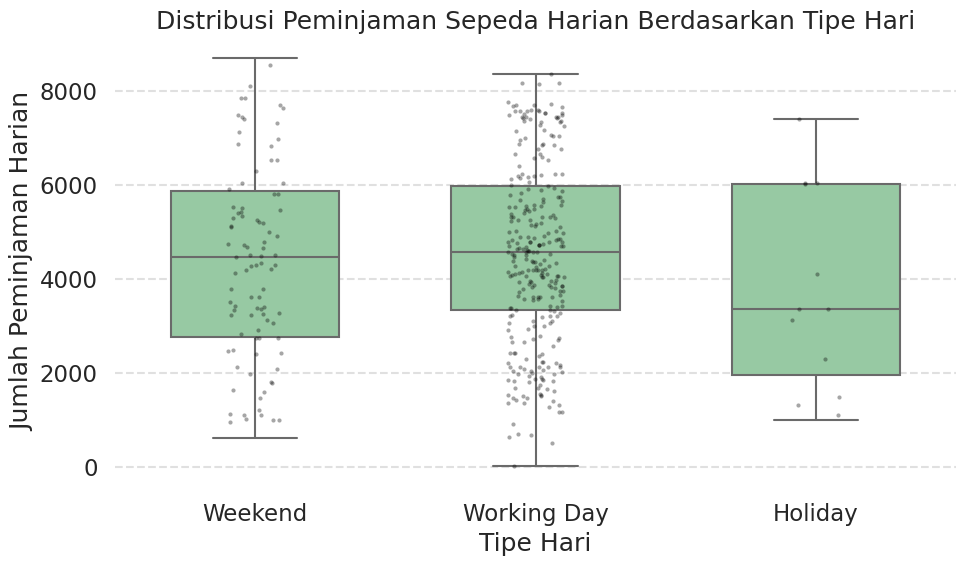

In [54]:
plt.figure(figsize=(10, 6))
ax = sns.boxplot(
    data=df,
    x="day_type",
    y="cnt",
    showfliers=False,
    width=0.6,
    linewidth=1.5,
    color="#8FD19E"
)

sns.stripplot(
    data=df.sample(min(len(df), 400), random_state=42),
    x="day_type",
    y="cnt",
    color="black",
    size=3,
    alpha=0.35
)

ax.set_title("Distribusi Peminjaman Sepeda Harian Berdasarkan Tipe Hari")
ax.set_xlabel("Tipe Hari")
ax.set_ylabel("Jumlah Peminjaman Harian")

ax.grid(axis="y", linestyle="--", alpha=0.6)
sns.despine(left=True, bottom=True)

plt.tight_layout()
plt.show()


**Insight:**
- Hari kerja (Working Day) memiliki jumlah peminjaman sepeda yang relatif lebih tinggi dan lebih stabil dibandingkan tipe hari lainnya.
- Akhir pekan (Weekend) menunjukkan tingkat peminjaman yang sedikit lebih rendah dengan variasi yang lebih besar antar hari.
- Hari libur (Holiday) memiliki jumlah peminjaman paling rendah dan distribusi yang paling tidak konsisten.
- Variasi peminjaman yang lebih besar pada akhir pekan dan hari libur mengindikasikan bahwa penggunaan sepeda pada hari non-kerja lebih dipengaruhi oleh faktor eksternal seperti cuaca dan aktivitas rekreasi.



## Analisis Lanjutan (Opsional)

## Conclusion

- Conclution pertanyaan 1 <br>
Kondisi cuaca terbukti memengaruhi jumlah peminjaman sepeda harian. cuaca cerah menghasilkan rata-rata peminjaman tertinggi, diikuti oleh kondisi berawan. Sebaliknya, hujan ringan secara signifikan menurunkan jumlah peminjaman sepeda. kesimpulannya adalah semakin buruk kondisi cuaca, semakin rendah intensitas penggunaan sepeda.
- Conclution pertanyaan 2 <br>
Terdapat perbedaan pola peminjaman sepeda harian berdasarkan tipe hari. Hari kerja memiliki rata-rata peminjaman tertinggi dan cenderung lebih stabil, sedangkan akhir pekan berada pada tingkat menengah dengan variasi yang lebih besar. Hari libur menunjukkan rata-rata peminjaman terendah dan pola penggunaan yang paling tidak konsisten dan sedikit. kesimpulannya adalah peminjaman sepeda pada hari kerja didorong oleh aktivitas rutin atau kegiatan sehari hari, sementara pada hari non-kerja lebih dipengaruhi oleh faktor lain yang membuat lebih sepi.